In [2]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker


os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

data_folder = "drive/MyDrive/mestrado_final_files/data/"
models_time_folder = "drive/MyDrive/mestrado_final_files/models/SpentTimeModel_TimeDiffTower/"
models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo_TimeDiffTower/"

#data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel_TimeDiffTower\\"
#models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_TimeDiffTower\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [5]:
with open(data_folder + 'data_time_features.pkl', 'rb') as f:
    df_time_features = pickle.load(f)

In [6]:
#%run 01_functions_training.ipynb
%run drive/MyDrive/mestrado_final_files/notebooks/01_functions_training.ipynb

In [7]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [8]:
list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_" in item and ".pth" in item]

In [9]:
VOCAB_SIZE = 601
TIME_SIZE = 301



In [10]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.

    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape

    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0

    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))

    return brier_score

In [11]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [12]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel" in item and ".pth" in item and str_season in item]

    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_time_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
           .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
           .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_stt = torch.from_numpy(np.asarray(df_["token_state"].to_list())).to(torch.int64)
    dev_y = df_["target_time"].values
    dev_mask = torch.tensor(build_logit_mask_spent_time_models(df_), dtype = torch.bool, device = device)

    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        index_num_covariables = dict_set_covariables["index"][5]
        num_covariables = dict_set_covariables["covariables"][5]

        index_tower_covariables = dict_set_covariables["index"][6]
        tower_covariables = dict_set_covariables["covariables"][6]

        time_model = SpentTimeModel_TimeDiffTower(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                                  embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(index_num_covariables),
                                                  time_diff_input_dim = len(index_tower_covariables), time_tower_hidden_dim = 16,
                                                  time_tower_out_dim = 16, num_hidden_neurons = num_hidden_neurons, num_layers = num_layers,
                                                  activation_function = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)

        time_model.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        time_model.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            output_model = time_model(dev_tkn[:, -CONTEXT_SIZE:], dev_num[:, index_tower_covariables], dev_num[:, index_num_covariables])
            output_model = output_model.masked_fill(dev_mask, -1e9)
            all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True, get_mae = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)


2018-19


100%|██████████| 16/16 [03:38<00:00, 13.63s/it]


2019-20


100%|██████████| 16/16 [03:16<00:00, 12.31s/it]


2020-21


100%|██████████| 16/16 [03:14<00:00, 12.16s/it]


2021-22


100%|██████████| 16/16 [03:35<00:00, 13.47s/it]


2022-23


100%|██████████| 16/16 [03:29<00:00, 13.08s/it]


In [13]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet", index = False, compression = "zstd")

In [14]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [15]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet", index = False, compression = "zstd")

In [16]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet", index = False, compression = "zstd")


In [ ]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_TimeDiffTower" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_time_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))



100%|██████████| 16/16 [00:00<00:00, 49.98it/s]


In [ ]:
df_parameters = pd.DataFrame(list_num_parametros, columns = ["modelname", "num_parameters"])

In [ ]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[2].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[3].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[4].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[5].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[6].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[7].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[8].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[9].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     5                   32                 50   
1                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                       56  49683  50265  54783  55565  
1                       56  76915  77817  82015  83117

In [ ]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")

In [ ]:
group_variables1 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [ ]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [ ]:
df_resultados2

,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,bs_mean,bs_std,cross_entropy_mean,...,mae_mean,mae_std,reliability_erro_mean,reliability_erro_std,resolution_poder_mean,resolution_poder_std,uncertainty_caos_mean,uncertainty_caos_std,bss_mean,bss_std
0,5,32,56,50,3,0.0,False,0.796462,0.004597,2.364767,...,24.141517,0.356589,0.002316,0.000096,0.137713,0.003910,0.951224,0.000533,0.162699,0.004493
1,5,32,56,50,3,0.0,True,0.797766,0.004774,2.378316,...,24.416614,0.355868,0.002695,0.000177,0.137142,0.003849,0.951224,0.000533,0.161328,0.004690
2,5,32,56,50,3,0.3,False,0.798774,0.004138,2.386362,...,24.770158,0.373911,0.002222,0.000154,0.134470,0.003696,0.951224,0.000533,0.160268,0.004061
3,5,32,56,50,3,0.3,True,0.798349,0.004345,2.386254,...,24.599059,0.373938,0.002751,0.000146,0.135830,0.003672,0.951224,0.000533,0.160715,0.004263
4,5,32,56,50,5,0.0,False,0.796142,0.004494,2.364725,...,24.130634,0.369340,0.002069,0.000172,0.137618,0.003956,0.951224,0.000533,0.163036,0.004405
5,5,32,56,50,5,0.0,True,0.797597,0.004429,2.378969,...,24.484347,0.372240,0.002635,0.000073,0.137115,0.003632,0.951224,0.000533,0.161506,0.004326
6,5,32,56,50,5,0.3,False,0.800566,0.004160,2.400265,...,24.917451,0.342729,0.002175,0.000211,0.132901,0.003674,0.951224,0.000533,0.158384,0.004053
7,5,32,56,50,5,0.3,True,0.800133,0.004339,2.400175,...,24.741960,0.338223,0.002718,0.000132,0.134351,0.003752,0.951224,0.000533,0.158839,0.004290
8,5,64,56,50,3,0.0,False,0.796627,0.004442,2.366145,...,24.147781,0.377111,0.002357,0.000114,0.137735,0.003868,0.951224,0.000533,0.162526,0.004341
9,5,64,56,50,3,0.0,True,0.798179,0.004297,2.378895,...,24.458355,0.436571,0.002713,0.000093,0.136643,0.003808,0.951224,0.000533,0.160894,0.004189


In [ ]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.3647 (0.0220) [2]  2.3783 (0.0237) [5]   
1                         56  2.3647 (0.0231) [1]  2.3789 (0.0221) [7]   
2                         56  2.3661 (0.0220) [3]  2.3788 (0.0227) [6]   
3                         56  2.3671 (0.0218) [4]  2.3806 (0.0233) [8]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3863 (0.0208) [11]  2.3862 (0.0229) [10]  
1             2.4002 (0.0208) [16]  2.4001 (0.0218) [15]  
2              2.3837 (0.0228) [9]  2.3864 (0.0241) [12]  
3             2.3988 (0.0213) [13]  2.3989 (0.0218) [14]

In [ ]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  0.1626 (0.0044) [3]  0.1613 (0.0046) [6]   
1                         56  0.1630 (0.0044) [1]  0.1615 (0.0043) [5]   
2                         56  0.1625 (0.0043) [4]  0.1608 (0.0041) [7]   
3                         56  0.1627 (0.0044) [2]  0.1607 (0.0044) [9]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1602 (0.0040) [12]  0.1607 (0.0042) [11]  
1             0.1583 (0.0040) [16]  0.1588 (0.0042) [14]  
2             0.1607 (0.0042) [10]   0.1608 (0.0044) [8]  
3             0.1585 (0.0039) [15]  0.1592 (0.0041) [13]

In [ ]:
df_resultados2\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  24.141 (0.3565) [2]  24.416 (0.3558) [5]   
1                         56  24.130 (0.3693) [1]  24.484 (0.3722) [8]   
2                         56  24.147 (0.3771) [3]  24.458 (0.4365) [6]   
3                         56  24.166 (0.3962) [4]  24.476 (0.4514) [7]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.770 (0.3739) [14]  24.599 (0.3739) [10]  
1             24.917 (0.3427) [16]  24.741 (0.3382) [13]  
2             24.727 (0.4124) [11]   24.538 (0.3765) [9]  
3             24.860 (0.3426) [15]  24.731 (0.3256) [12]

In [ ]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["embedding_layer_size"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	8.0	8.375	5.604526	1.0	4.25	8.5	12.00	16.0
# 1	64	8.0	8.625	4.138236	3.0	5.50	8.5	12.25	14.0

# num_layers
# 0	3	8.0	7.25	3.770184	2.0	4.50	 7.5	10.25	12.0
# 1	5	8.0	9.75	5.548488	1.0	6.25	10.5	14.25	16.0

# set_covariables
#0	56	16.0	8.5	4.760952	1.0	4.75	8.5	12.25	16.0


# dropout_rate
# 0	0.0	8.0	 4.5	2.44949	1.0	 2.75	 4.5	 6.25	 8.0
# 1	0.3	8.0	12.5	2.44949	9.0	10.75	12.5	14.25	16.0

# layer_norm
# 0	False	8.0	7.375	5.629958	1.0	2.75	6.5	11.5	16.0
# 1	True	8.0	9.625	3.739270	5.0	6.75	9.0	12.5	15.0

# layer_norm, dropout_rate
# 0	False	0.0	4.0	 2.50	1.290994	 1.0	 1.75	 2.5	 3.25	 4.0
# 1	False	0.3	4.0	12.25	2.986079	 9.0	10.50	12.0	13.75	16.0
# 2	True	0.0	4.0	 6.50	1.290994	 5.0	 5.75	 6.5	 7.25	 8.0
# 3	True	0.3	4.0	12.75	2.217356	10.0	11.50	13.0	14.25	15.0




,embedding_layer_size,count,mean,std,min,25%,50%,75%,max
0,32,8.0,8.375,5.604526,1.0,4.25,8.5,12.00,16.0
1,64,8.0,8.625,4.138236,3.0,5.50,8.5,12.25,14.0


In [ ]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

# embedding_layer_size
# 0	32	8.0	8.5	5.477226	1.0	4.50	8.5	12.50	16.0
# 1	64	8.0	8.5	4.309458	2.0	6.25	8.5	10.75	15.0

# num_layers
# 0	3	8.0	7.625	3.248626	3.0	5.50	 7.5	10.25	12.0
# 1	5	8.0	9.375	6.022280	1.0	4.25	11.0	14.25	16.0

# set_covariables
# 0	56	16.0	8.5	4.760952	1.0	4.75	8.5	12.25	16.0

# dropout_rate
# 0	0.0	8.0	4.625	2.66927	1.0	 2.75	 4.5	 6.25	 9.0
# 1	0.3	8.0	12.375	2.66927	8.0	10.75	12.5	14.25	16.0

# layer_norm
# 0	False	8.0	7.875	6.081295	1.0	2.75	7.0	12.75	16.0
# 1	True	8.0	9.125	3.270539	5.0	6.75	8.5	11.50	14.0


# layer_norm, dropout_rate
# 0	False	0.0	4.0	 2.50	1.290994	 1.0	 1.75	 2.5	 3.25	 4.0
# 1	False	0.3	4.0	13.25	2.753785	10.0	11.50	13.5	15.25	16.0
# 2	True	0.0	4.0	 6.75	1.707825	 5.0	 5.75	 6.5	 7.50	 9.0
# 3	True	0.3	4.0	11.50	2.645751	 8.0	10.25	12.0	13.25	14.0


,layer_norm,dropout_rate,count,mean,std,min,25%,50%,75%,max
0,False,0.0,4.0,2.50,1.290994,1.0,1.75,2.5,3.25,4.0
1,False,0.3,4.0,13.25,2.753785,10.0,11.50,13.5,15.25,16.0
2,True,0.0,4.0,6.75,1.707825,5.0,5.75,6.5,7.50,9.0
3,True,0.3,4.0,11.50,2.645751,8.0,10.25,12.0,13.25,14.0


In [ ]:
df_resultados1\
.pivot_table(index = group_variables1, columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,5,32,56,50,3,0.0,False,0.157527,0.162679,0.159433,0.164983,0.168873
1,5,32,56,50,3,0.0,True,0.156666,0.160449,0.157694,0.163663,0.168169
2,5,32,56,50,3,0.3,False,0.156250,0.158526,0.157837,0.162445,0.166280
3,5,32,56,50,3,0.3,True,0.156200,0.159433,0.158044,0.162991,0.166909
4,5,32,56,50,5,0.0,False,0.158614,0.161847,0.159861,0.165432,0.169425
5,5,32,56,50,5,0.0,True,0.157251,0.160425,0.158170,0.163986,0.167697
6,5,32,56,50,5,0.3,False,0.153765,0.157476,0.155848,0.160899,0.163933
7,5,32,56,50,5,0.3,True,0.154822,0.156583,0.156444,0.161044,0.165304
8,5,64,56,50,3,0.0,False,0.157971,0.161599,0.159358,0.165074,0.168627
9,5,64,56,50,3,0.0,True,0.156732,0.159494,0.157808,0.163807,0.166630


In [ ]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TIME_MODEL.parquet")

In [ ]:
group_variables2 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [ ]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables2 + ["seasondata", "brier_score_multinomial", "cross_entropy", "mae"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [ ]:
df_resultados4 = df_resultados3\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                         56  1.7375 (0.0624) [3]   1.8382 (0.0490) [9]   
1                         56  1.6835 (0.0705) [1]  1.8465 (0.0670) [10]   
2                         56  1.7449 (0.0700) [4]  1.8576 (0.0577) [11]   
3                         56  1.7178 (0.0624) [2]  1.8669 (0.0668) [12]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.8049 (0.0651) [8]  1.8831 (0.0560) [13]  
1             1.7898 (0.0750) [6]  1.9152 (0.0426) [15]  
2             1.7929 (0.0623) [7]  1.8873 (0.0467) [14]  
3             1.7890 (0.0750) [5]  1.9191 (0.0601) [16]

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                         56  0.4208 (0.0183) [5]  0.3863 (0.0099) [10]   
1                         56  0.4492 (0.0193) [1]   0.3872 (0.0088) [9]   
2                         56  0.4191 (0.0159) [6]  0.3790 (0.0113) [12]   
3                         56  0.4365 (0.0152) [2]  0.3783 (0.0127) [14]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             0.4107 (0.0178) [8]  0.3813 (0.0135) [11]  
1             0.4285 (0.0183) [3]  0.3734 (0.0102) [15]  
2             0.4148 (0.0129) [7]  0.3787 (0.0117) [13]  
3             0.4221 (0.0209) [4]  0.3732 (0.0113) [16]

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   
2                       5                   64                 50          3   
3                       5                   64                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  4.9216 (0.3792) [2]  5.6096 (0.4302) [5]   
1                         56  4.7576 (0.5382) [1]  5.7669 (0.4561) [8]   
2                         56  5.0137 (0.4770) [4]  5.7383 (0.4860) [6]   
3                         56  4.9785 (0.4608) [3]  5.7486 (0.5658) [7]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             6.5417 (0.5499) [13]  6.5139 (0.4273) [12]  
1             6.7486 (0.7480) [15]  6.6721 (0.4941) [14]  
2              6.3166 (0.5300) [9]  6.4854 (0.3063) [11]  
3             6.3961 (0.4823) [10]  6.8217 (0.5052) [16]

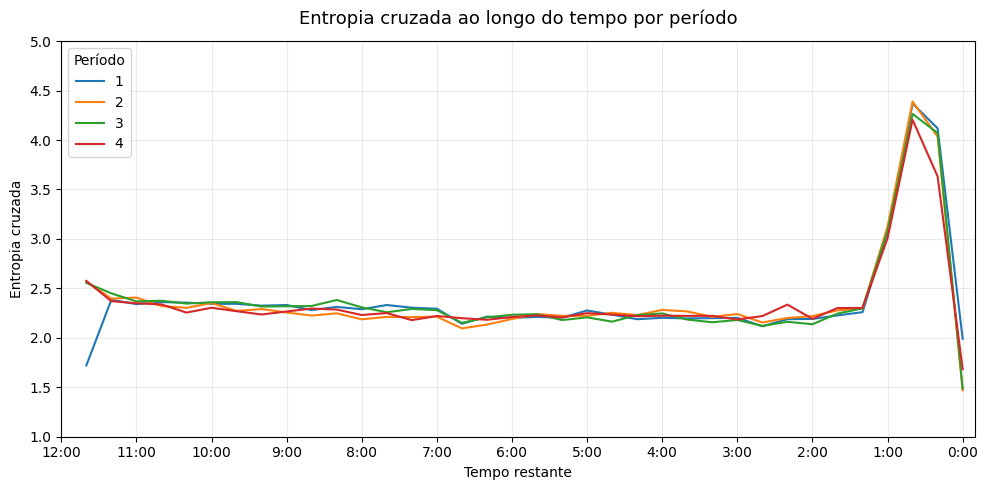

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(1, 5)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



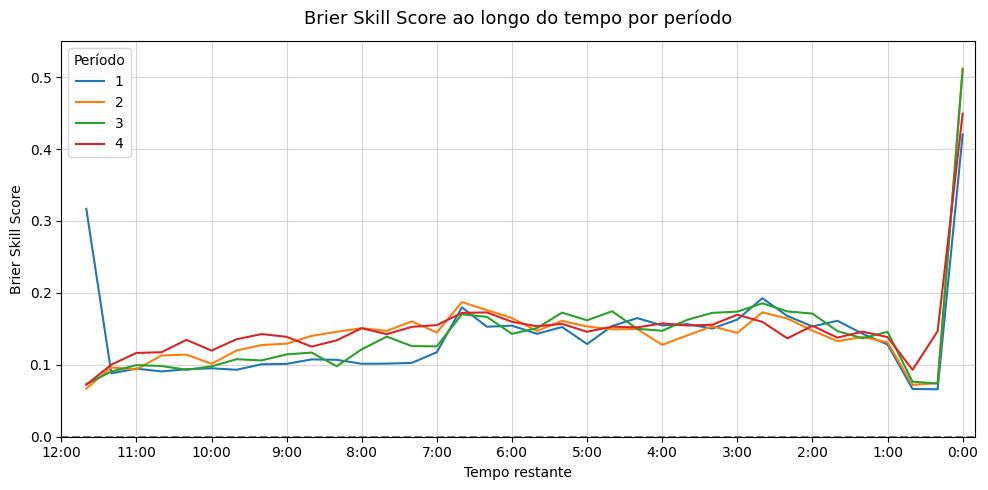

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(0, 0.55)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.5)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



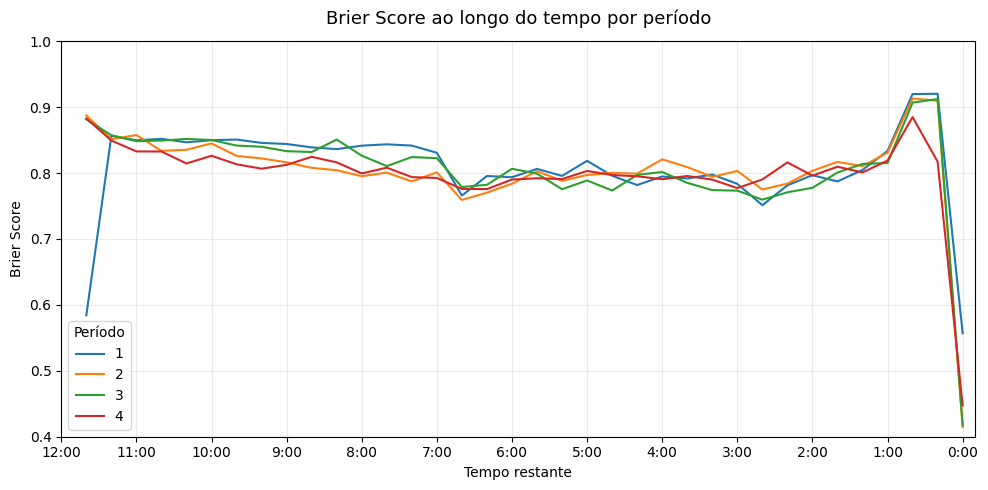

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



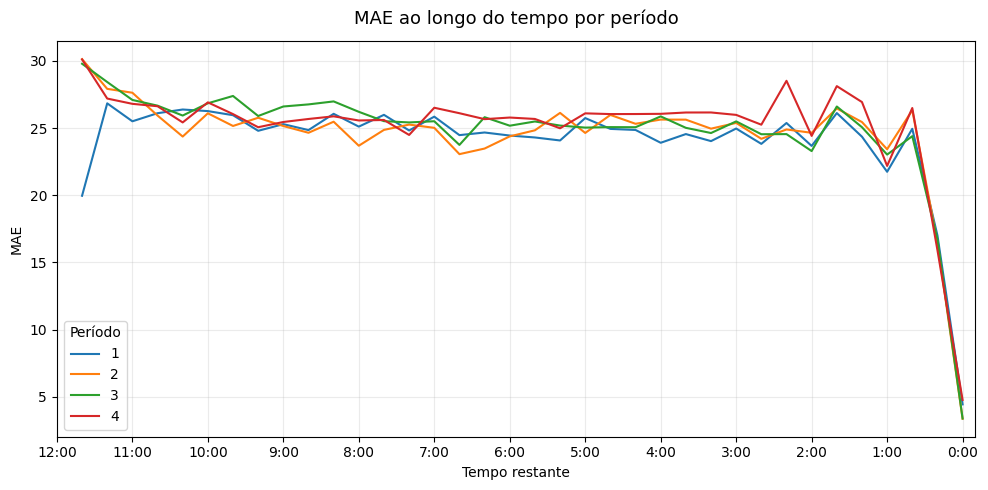

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 56")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "mae_mean")\
.plot(ax = ax)

#ax.set_ylim(0.4, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("MAE ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("MAE")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



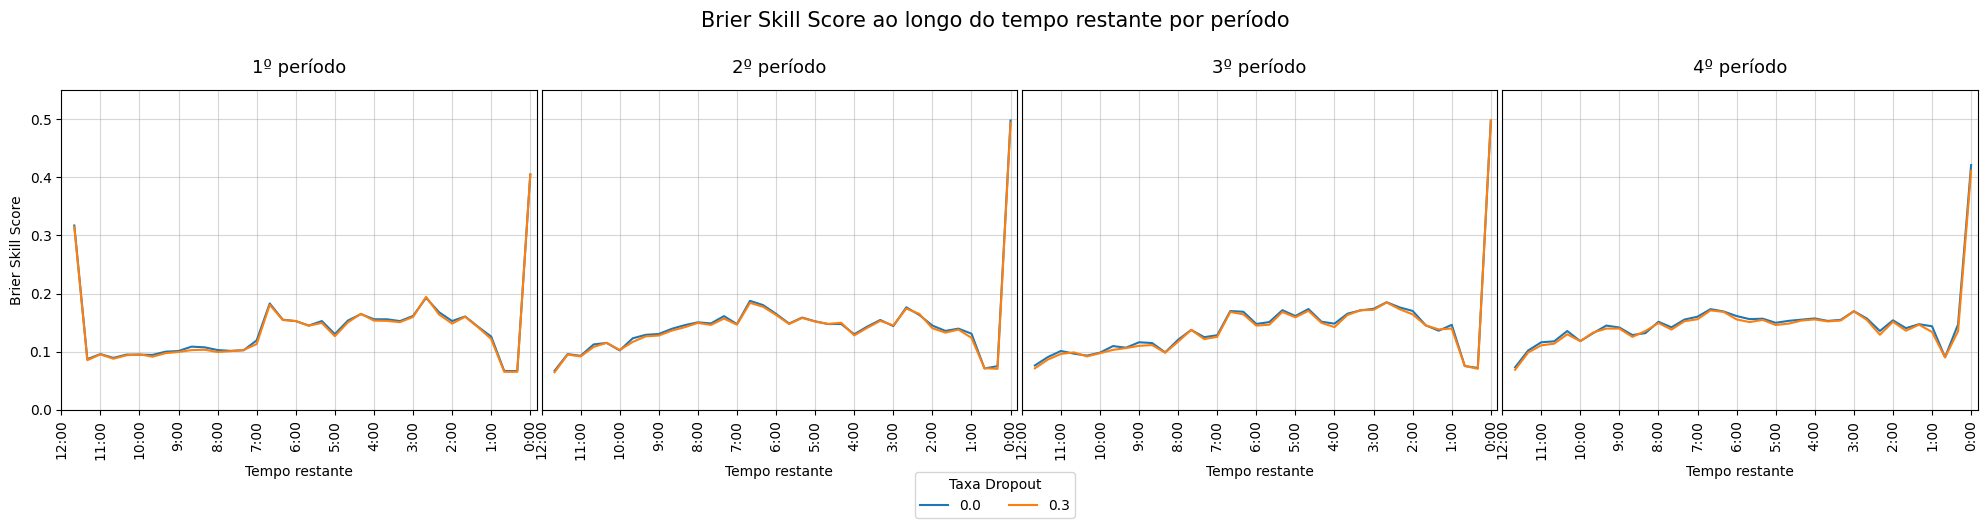

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & layer_norm == 0 & num_layers == 3 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0, 0.55)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

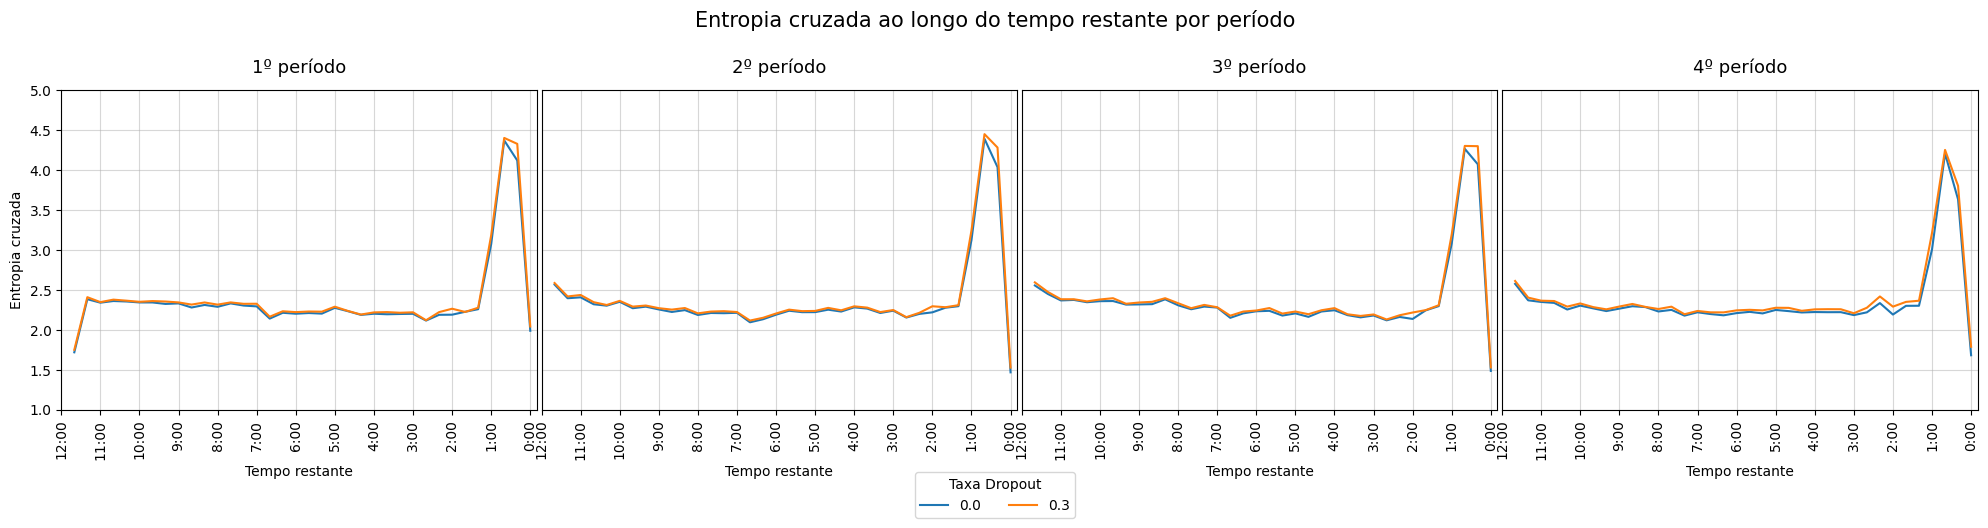

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

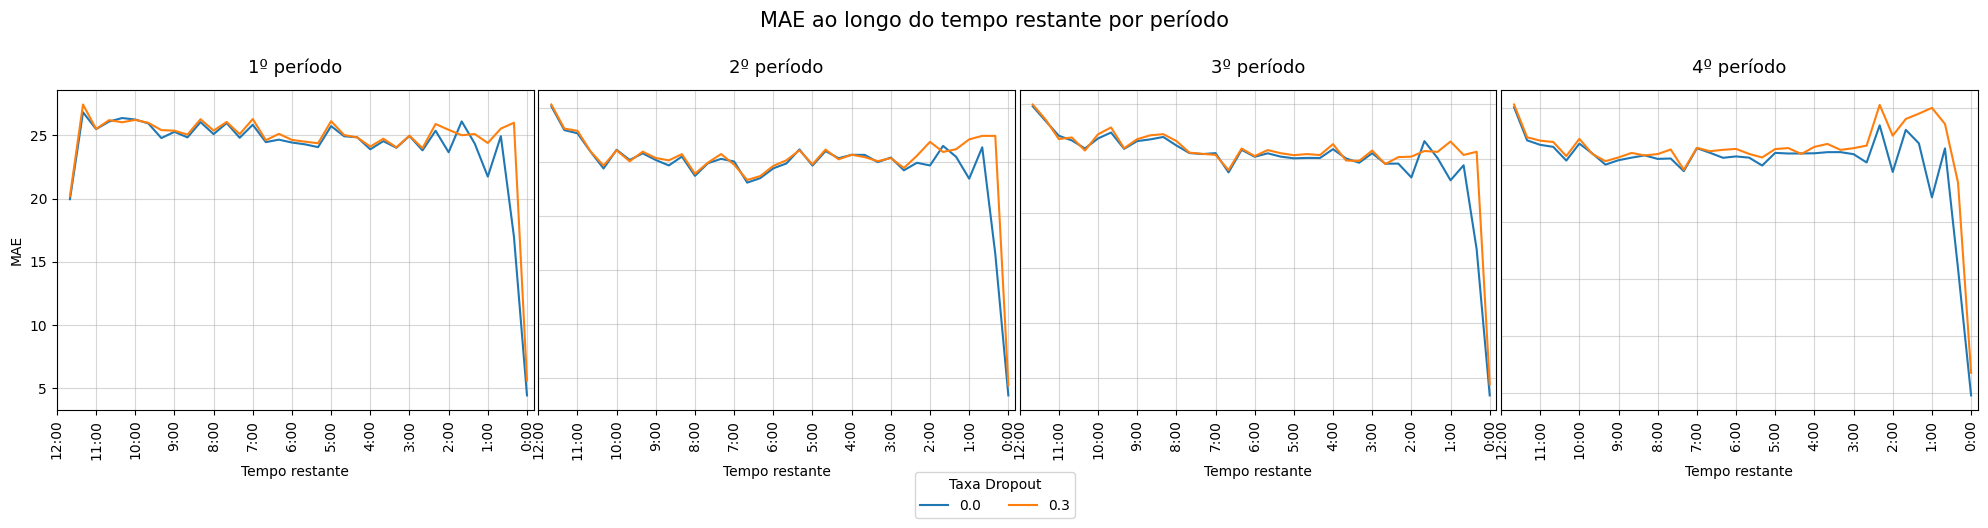

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "mae_mean")\
    .plot(ax = ax[i], legend=False)

    #ax[i].set_ylim(1, 5)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [ ]:
df_resultados4

,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,bs_mean,...,mae_mean,mae_std,reliability_erro_mean,reliability_erro_std,resolution_poder_mean,resolution_poder_std,uncertainty_caos_mean,uncertainty_caos_std,bss_mean,bss_std
0,1,0-200,5,32,56,50,3,0.0,False,0.572194,...,4.641177,0.228717,0.070835,0.006005,0.450250,0.016815,0.961000,0.004742,0.404572,0.015859
1,1,0-200,5,32,56,50,3,0.0,True,0.581804,...,4.962242,0.414671,0.073796,0.006897,0.443985,0.020351,0.961000,0.004742,0.394588,0.018087
2,1,0-200,5,32,56,50,3,0.3,False,0.571939,...,5.426265,0.327825,0.067154,0.008415,0.446188,0.010486,0.961000,0.004742,0.404852,0.015692
3,1,0-200,5,32,56,50,3,0.3,True,0.586042,...,5.100052,0.385386,0.079662,0.008281,0.445896,0.016209,0.961000,0.004742,0.390184,0.011918
4,1,0-200,5,32,56,50,5,0.0,False,0.557044,...,4.427213,0.403981,0.066237,0.003812,0.461487,0.016506,0.961000,0.004742,0.420334,0.016063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2539,5,800-1000,5,64,56,50,3,0.3,True,0.834237,...,31.067560,4.660572,0.114673,0.056556,0.189755,0.038280,0.893785,0.037694,0.065556,0.041068
2540,5,800-1000,5,64,56,50,5,0.0,False,0.819305,...,28.583755,5.941359,0.123424,0.032861,0.212750,0.024388,0.893785,0.037694,0.082687,0.041646
2541,5,800-1000,5,64,56,50,5,0.0,True,0.818846,...,28.302164,5.819883,0.128571,0.022982,0.210520,0.037853,0.893785,0.037694,0.082217,0.053515
2542,5,800-1000,5,64,56,50,5,0.3,False,0.837516,...,31.359391,4.923910,0.126401,0.039863,0.197643,0.040223,0.893785,0.037694,0.061970,0.039153


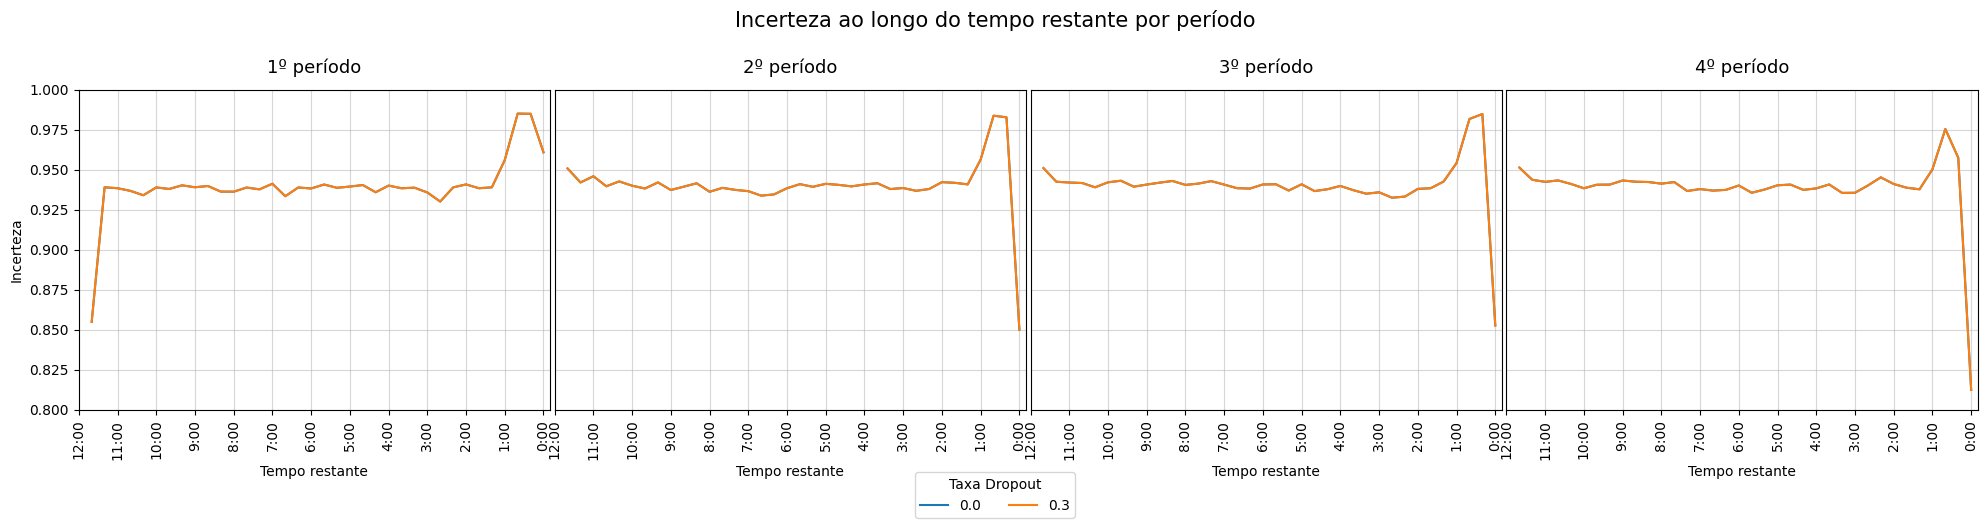

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "uncertainty_caos_mean")\
    .plot(ax = ax[i], legend = False)

    ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Incerteza")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Incerteza ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

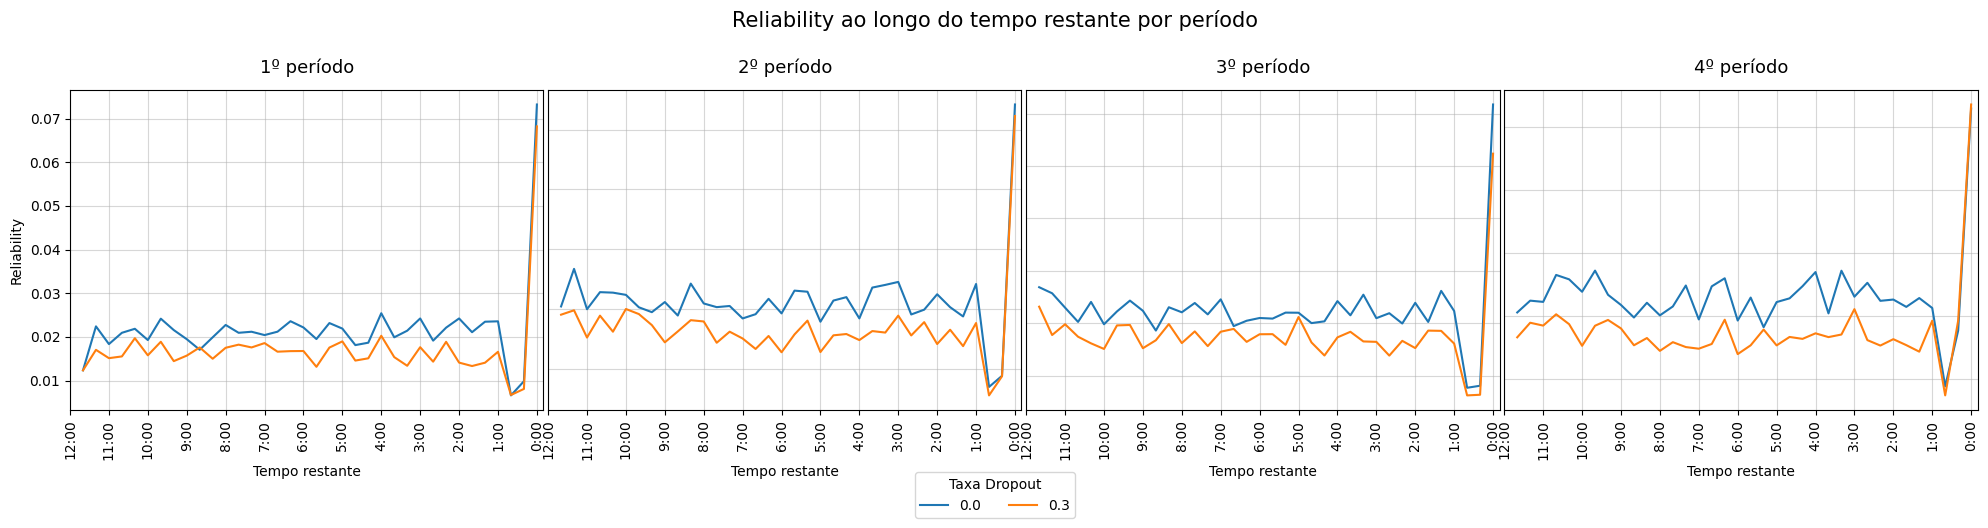

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend = False)

    #ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Reliability")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Reliability ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

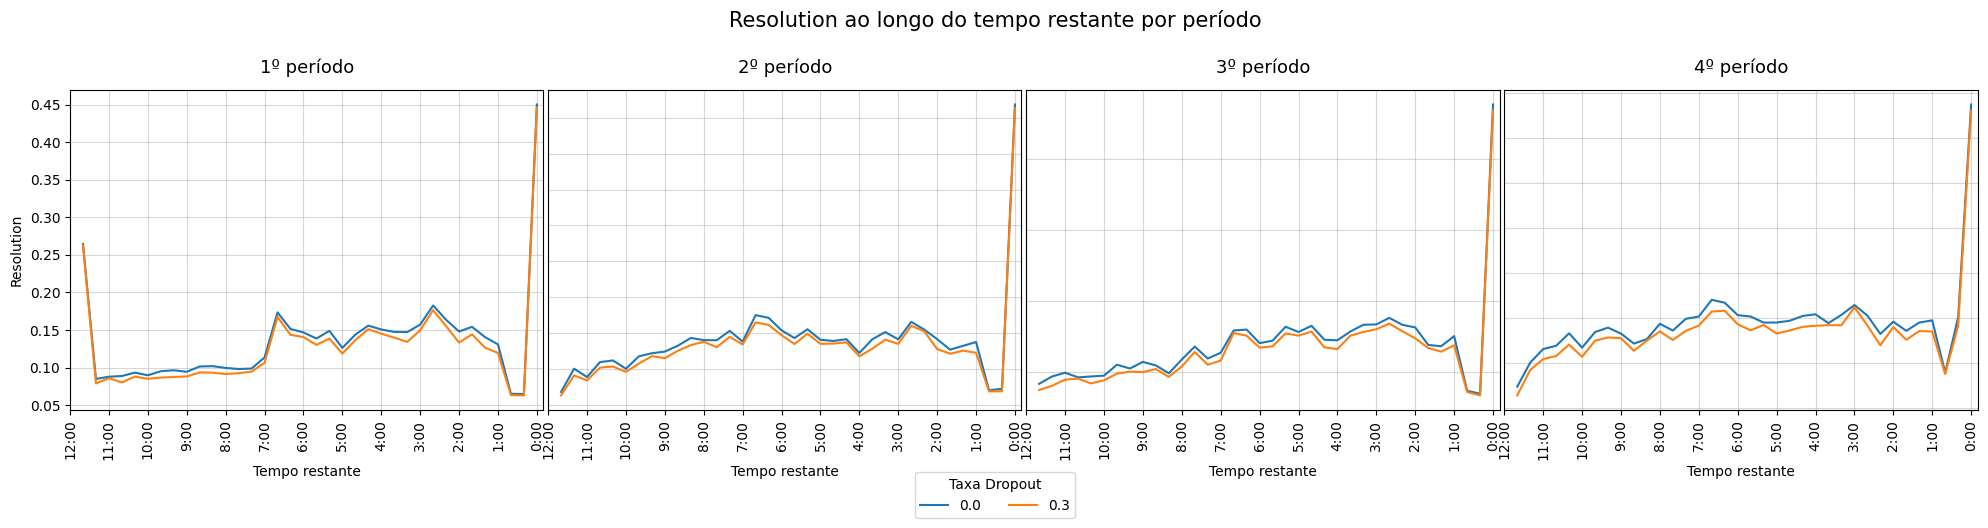

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(4):
    df_resultados4\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & set_covariables == 56")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "dropout_rate", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend = False)

    #ax[i].set_ylim(0.8, 1)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha=0.5)
    ax[i].set_title(f"{i+1}º período", fontsize=13, pad=12)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolution")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolution ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Taxa Dropout",
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
fig.subplots_adjust(wspace=0.01, top=0.82, bottom=0.18)
plt.show()

In [ ]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()

seasondata,period,cat_time,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,201819,201920,202021,202122,202223
0,4,0-200,5,32,56,50,3,0.0,False,0.421732,0.437381,0.416165,0.392511,0.436502
1,4,0-200,5,32,56,50,3,0.0,True,0.399234,0.391805,0.379835,0.373953,0.387126
2,4,0-200,5,32,56,50,3,0.3,False,0.428115,0.414342,0.415748,0.380584,0.415181
3,4,0-200,5,32,56,50,3,0.3,True,0.397315,0.387932,0.381713,0.360652,0.379062
4,4,0-200,5,32,56,50,5,0.0,False,0.469089,0.453260,0.437149,0.422541,0.464287
5,4,0-200,5,32,56,50,5,0.0,True,0.394427,0.396611,0.376565,0.379761,0.388717
6,4,0-200,5,32,56,50,5,0.3,False,0.450686,0.433119,0.416790,0.404036,0.438151
7,4,0-200,5,32,56,50,5,0.3,True,0.388211,0.365606,0.377969,0.362349,0.372904
8,4,0-200,5,64,56,50,3,0.0,False,0.441718,0.424165,0.404782,0.402699,0.422224
9,4,0-200,5,64,56,50,3,0.0,True,0.391131,0.385713,0.366056,0.367951,0.384614
